In [2]:
# ============================================
# CELL 1: SETUP & CONFIGURATION
# ============================================

!pip install -q torch torchvision transformers pillow matplotlib tqdm numpy pandas scikit-learn seaborn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from transformers import (
    BertModel, BertTokenizer,
    GPT2LMHeadModel, GPT2Tokenizer,
    get_cosine_schedule_with_warmup
)
from torchvision import models
from PIL import Image
import json
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)

# GPU Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("="*70)
print("SYSTEM CONFIGURATION")
print("="*70)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB")
print(f"Random Seed: 42")
print("="*70)

d:\anaconda3\envs\gpu_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SYSTEM CONFIGURATION
PyTorch version: 2.7.1+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
GPU Memory: 6.44 GB
Random Seed: 42


In [3]:
# ============================================
# CELL 2: DATASET CLASS WITH COMPLEXITY LABELS
# ============================================

class VQADataset(Dataset):
    """VQA Dataset with automatic complexity labeling"""
    
    def __init__(self, questions_path, annotations_path, image_folder, split='train'):
        print(f"\n Loading {split} dataset...")
        
        # Load data
        with open(questions_path, 'r') as f:
            self.questions = json.load(f)['questions']
        
        with open(annotations_path, 'r') as f:
            annotations = json.load(f)['annotations']
            self.qid_to_ann = {ann['question_id']: ann for ann in annotations}
        
        self.image_folder = image_folder
        self.split = split
        
        # Build complexity labels and answer vocabulary
        all_answers = []
        self.question_complexities = []
        
        # Complexity mapping
        perceptual_keywords = ['color', 'count', 'is', 'are', 'does', 'number']
        reasoning_keywords = ['why', 'how', 'what if', 'could', 'would']
        
        for q in self.questions:
            ann = self.qid_to_ann.get(q['question_id'])
            if ann:
                answer = ann['multiple_choice_answer'].lower()
                all_answers.append(answer)
                
                # Assign complexity based on question
                q_type = ann.get('question_type', '').lower()
                if any(k in q_type for k in perceptual_keywords):
                    self.question_complexities.append(0)  # Perceptual
                else:
                    self.question_complexities.append(1)  # Reasoning
        
        # Build answer vocabulary (top 1000 answers)
        counter = Counter(all_answers)
        common_answers = [ans for ans, _ in counter.most_common(1000)]
        self.answer_list = ['<unk>'] + common_answers
        self.ans_to_idx = {ans: idx for idx, ans in enumerate(self.answer_list)}
        self.idx_to_ans = {idx: ans for idx, ans in enumerate(self.answer_list)}
        
        # Load tokenizer
        self.tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        
        print(f"   ✓ {len(self.questions)} questions loaded")
        print(f"   ✓ Answer vocabulary: {len(self.answer_list)}")
        print(f"   ✓ Complexity distribution: {Counter(self.question_complexities)}")
    
    def __len__(self):
        return len(self.questions)
    
    def __getitem__(self, idx):
        q = self.questions[idx]
        ann = self.qid_to_ann.get(q['question_id'], {})
        
        # Load and preprocess image
        img_id = q['image_id']
        img_id_str = str(img_id).zfill(12)
        img_path = f"{self.image_folder}/COCO_train2014_{img_id_str}.jpg"
        if not os.path.exists(img_path):
            img_path = img_path.replace('train2014', 'val2014')
        
        try:
            image = Image.open(img_path).convert('RGB')
            image = image.resize((224, 224))
            image = np.array(image).transpose(2, 0, 1) / 255.0
            image = torch.FloatTensor(image)
        except:
            image = torch.zeros(3, 224, 224)
        
        # Tokenize question
        question = q['question']
        tokens = self.tokenizer(
            question,
            padding='max_length',
            truncation=True,
            max_length=32,
            return_tensors='pt'
        )
        
        # Get answer and complexity
        answer_text = ann.get('multiple_choice_answer', '<unk>').lower()
        answer_label = self.ans_to_idx.get(answer_text, 0)
        complexity = self.question_complexities[idx]
        
        return {
            'image': image,
            'input_ids': tokens['input_ids'].squeeze(0),
            'attention_mask': tokens['attention_mask'].squeeze(0),
            'label': torch.tensor(answer_label),
            'complexity': torch.tensor(complexity),
            'question': question,
            'answer_text': answer_text,
            'image_id': img_id
        }

In [4]:
# ============================================
# CELL 3: LOAD DATASETS 
# ============================================

base_path = '.'  # Update this to your data path

# Load datasets
train_dataset = VQADataset(
    f'{base_path}/data/mini_train_questions.json',
    f'{base_path}/data/mini_train_annotations.json',
    f'{base_path}/data/mini_coco/train2014',
    split='train'
)

val_dataset = VQADataset(
    f'{base_path}/data/mini_val_questions.json',
    f'{base_path}/data/mini_val_annotations.json',
    f'{base_path}/data/mini_coco/val2014',
    split='val'
)

# Fixed collate function - NO COMMENTS INSIDE!
def collate_fn(batch):
    images = torch.stack([b['image'] for b in batch])
    input_ids = torch.stack([b['input_ids'] for b in batch])
    attention_mask = torch.stack([b['attention_mask'] for b in batch])
    labels = torch.stack([b['label'] for b in batch])
    complexities = torch.stack([b['complexity'] for b in batch])
    
    questions = [b['question'] for b in batch]
    answer_texts = [b['answer_text'] for b in batch]
    image_ids = [b['image_id'] for b in batch]
    
    return {
        'image': images,
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'label': labels,
        'complexity': complexities,
        'question': questions,
        'answer_text': answer_texts,
        'image_id': image_ids
    }

# Create dataloaders with drop_last=True
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

print("\n" + "="*70)
print("DATASET SUMMARY")
print("="*70)
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Batch size: 32")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Drop last: True (removes incomplete batches)")
print("="*70)


 Loading train dataset...
   ✓ 27407 questions loaded
   ✓ Answer vocabulary: 1001
   ✓ Complexity distribution: Counter({0: 17760, 1: 9647})

 Loading val dataset...
   ✓ 5214 questions loaded
   ✓ Answer vocabulary: 1001
   ✓ Complexity distribution: Counter({0: 3311, 1: 1903})

DATASET SUMMARY
Training samples: 27407
Validation samples: 5214
Batch size: 32
Train batches: 856
Val batches: 162
Drop last: True (removes incomplete batches)


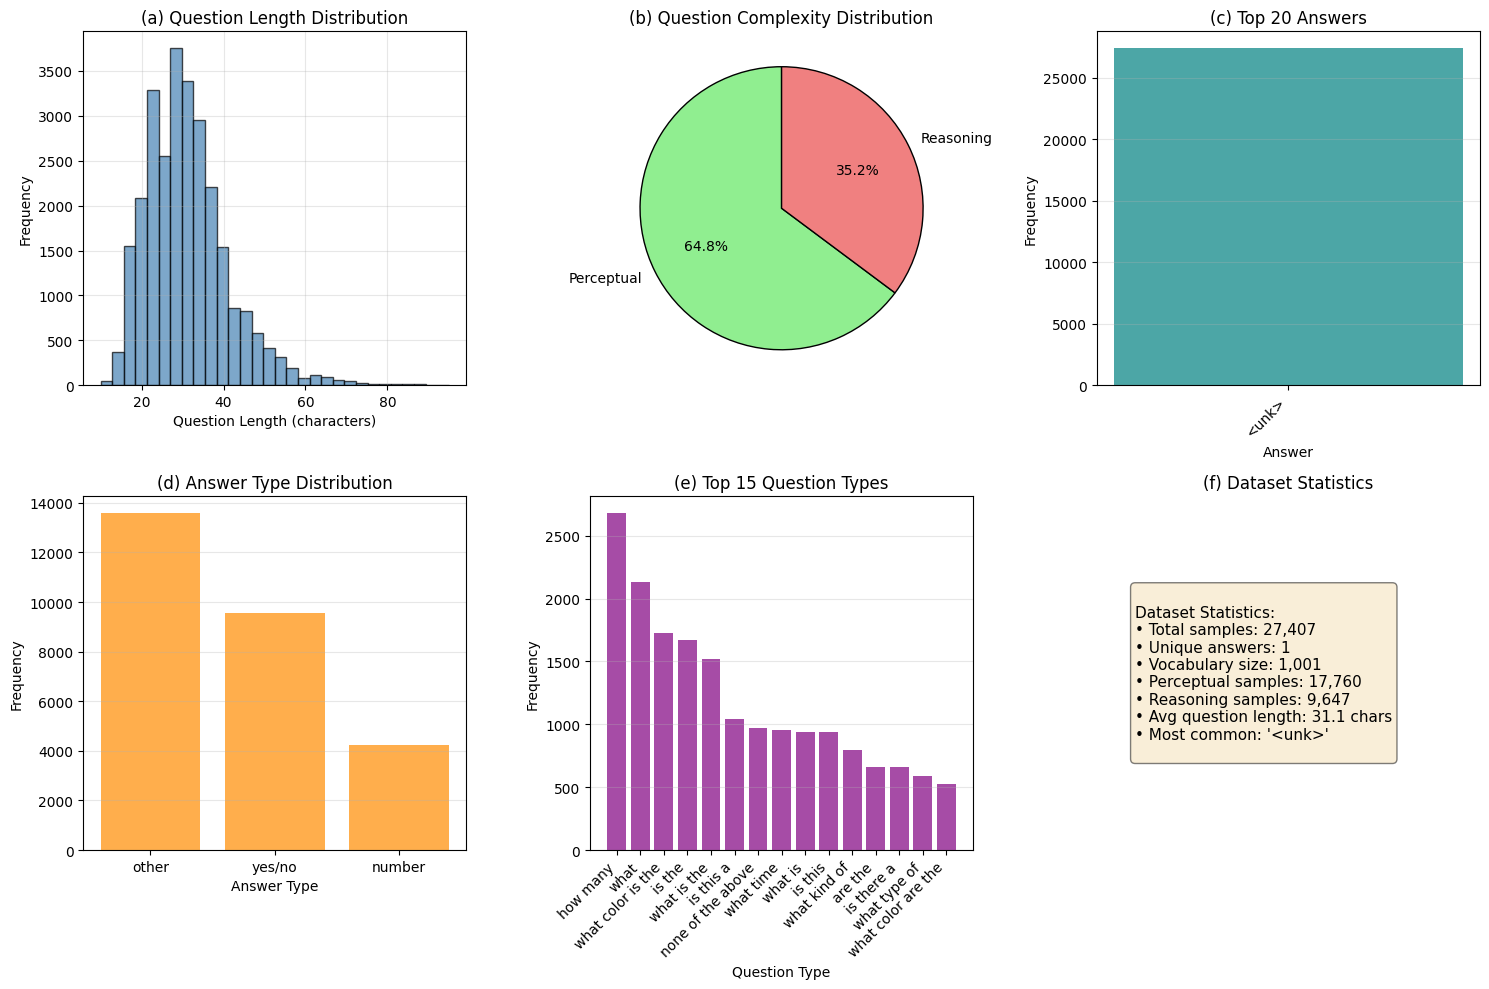


 EDA complete! Figure saved as 'eda_analysis.png'


In [5]:
# ============================================
# CELL 4: EXPLORATORY DATA ANALYSIS
# ============================================

# Analyze training data
df = pd.DataFrame([
    {
        'question': q['question'],
        'complexity': 'Perceptual' if c == 0 else 'Reasoning',
        'answer': train_dataset.idx_to_ans.get(l, '<unk>')
    }
    for q, c, l in zip(train_dataset.questions, 
                        train_dataset.question_complexities,
                        [train_dataset.qid_to_ann.get(q['question_id'], {}).get('multiple_choice_answer', '<unk>') 
                         for q in train_dataset.questions])
])

# Create publication-quality figures
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Question Length Distribution
df['q_len'] = df['question'].apply(len)
axes[0, 0].hist(df['q_len'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Question Length (characters)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('(a) Question Length Distribution')
axes[0, 0].grid(True, alpha=0.3)

# 2. Complexity Distribution
complexity_counts = df['complexity'].value_counts()
axes[0, 1].pie(complexity_counts.values, labels=complexity_counts.index,
               autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'],
               startangle=90, wedgeprops={'edgecolor': 'black'})
axes[0, 1].set_title('(b) Question Complexity Distribution')

# 3. Top 20 Answers
top_answers = df['answer'].value_counts().head(20)
axes[0, 2].bar(range(len(top_answers)), top_answers.values, color='teal', alpha=0.7)
axes[0, 2].set_xticks(range(len(top_answers)))
axes[0, 2].set_xticklabels(top_answers.index, rotation=45, ha='right')
axes[0, 2].set_xlabel('Answer')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('(c) Top 20 Answers')
axes[0, 2].grid(True, alpha=0.3, axis='y')

# 4. Answer Type Distribution
answer_types = [ann.get('answer_type', 'other') for ann in train_dataset.qid_to_ann.values()]
type_counts = Counter(answer_types)
axes[1, 0].bar(type_counts.keys(), type_counts.values(), color='darkorange', alpha=0.7)
axes[1, 0].set_xlabel('Answer Type')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('(d) Answer Type Distribution')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 5. Question Types
question_types = [ann.get('question_type', 'other') for ann in train_dataset.qid_to_ann.values()]
type_counts = Counter(question_types).most_common(15)
axes[1, 1].bar([t[0] for t in type_counts], [t[1] for t in type_counts], 
               color='purple', alpha=0.7)
axes[1, 1].set_xticklabels([t[0] for t in type_counts], rotation=45, ha='right')
axes[1, 1].set_xlabel('Question Type')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('(e) Top 15 Question Types')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 6. Dataset Statistics
axes[1, 2].axis('off')
stats_text = f"""
Dataset Statistics:
• Total samples: {len(train_dataset):,}
• Unique answers: {df['answer'].nunique():,}
• Vocabulary size: {len(train_dataset.answer_list):,}
• Perceptual samples: {complexity_counts['Perceptual']:,}
• Reasoning samples: {complexity_counts['Reasoning']:,}
• Avg question length: {df['q_len'].mean():.1f} chars
• Most common: '{df['answer'].mode()[0]}'
"""
axes[1, 2].text(0.1, 0.5, stats_text, fontsize=11, 
                verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 2].set_title('(f) Dataset Statistics')

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n EDA complete! Figure saved as 'eda_analysis.png'")

In [6]:
# ============================================
# CELL 5: NOVEL ADAPTIVE FUSION VQA MODEL 
# ============================================

class AdaptiveFusionVQA(nn.Module):
    """
    Novel VQA Model with Question-Complexity Adaptive Fusion
    
    Key Contributions:
    1. Question Complexity Analyzer
    2. Adaptive Fusion Weight α based on complexity
    3. Dual-output: Classifier + GPT-2 Generator
    """
    
    def __init__(self, num_answers):
        super().__init__()
        
        # 1. Image Encoder (ResNet18 - efficient)
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.resnet = nn.Sequential(*list(self.resnet.children())[:-1])
        for param in self.resnet.parameters():
            param.requires_grad = False
        self.resnet_proj = nn.Linear(512, 256)
        
        # 2. Text Encoder (BERT - frozen)
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        for param in self.bert.parameters():
            param.requires_grad = False
        
        # 3. NOVEL: Question Complexity Analyzer
        self.complexity_analyzer = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)  # 2 complexity levels
        )
        
        # 4. NOVEL: Adaptive Fusion Controller
        self.fusion_controller = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        
        # 5. Answer Classifier
        self.classifier = nn.Sequential(
            nn.Linear(256 + 768, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_answers)
        )
        
        # 6. GPT-2 Generator (for descriptive answers) - FIXED: Properly configured
        self.gpt2 = GPT2LMHeadModel.from_pretrained('gpt2')
        self.gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        self.gpt2_tokenizer.pad_token = self.gpt2_tokenizer.eos_token
        self.gpt2_tokenizer.padding_side = "left"
        for param in self.gpt2.parameters():
            param.requires_grad = False
        
        self.gpt2_proj = nn.Linear(256 + 768, 768)
        
        # Initialize weights
        self._init_weights()
        
        # Count parameters
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        
        print("\n" + "="*70)
        print("MODEL ARCHITECTURE")
        print("="*70)
        print(f"Total parameters: {total_params:,}")
        print(f"Trainable parameters: {trainable_params:,}")
        print(f"Trainable %: {100*trainable_params/total_params:.2f}%")
        print("\nComponents:")
        print("  • Image Encoder: ResNet18 (frozen)")
        print("  • Text Encoder: BERT (frozen)")
        print("  • Complexity Analyzer: Custom (trainable)")
        print("  • Fusion Controller: Custom (trainable)")
        print("  • Classifier: Custom (trainable)")
        print("  • GPT-2 Generator: (frozen)")
        print("="*70)
    
    def _init_weights(self):
        for module in [self.complexity_analyzer, self.fusion_controller, 
                      self.classifier, self.resnet_proj, self.gpt2_proj]:
            for layer in module.modules():
                if isinstance(layer, nn.Linear):
                    nn.init.xavier_uniform_(layer.weight)
                    if layer.bias is not None:
                        nn.init.zeros_(layer.bias)
    
    def forward(self, image, input_ids, attention_mask, 
                question_texts=None, answer_texts=None, mode='train'):
        
        # Extract image features
        img_feat = self.resnet(image).squeeze(-1).squeeze(-1)
        img_feat = self.resnet_proj(img_feat)  # [batch, 256]
        
        # Extract text features
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        txt_feat = bert_out.last_hidden_state[:, 0, :]  # [batch, 768]
        
        # Verify batch sizes match
        batch_size = image.size(0)
        assert img_feat.size(0) == batch_size, f"Image features batch size mismatch: {img_feat.size(0)} vs {batch_size}"
        assert txt_feat.size(0) == batch_size, f"Text features batch size mismatch: {txt_feat.size(0)} vs {batch_size}"
        
        # NOVEL: Analyze question complexity
        complexity_logits = self.complexity_analyzer(txt_feat)
        complexity_probs = torch.softmax(complexity_logits, dim=1)
        
        # NOVEL: Generate adaptive fusion weight α
        alpha = self.fusion_controller(complexity_probs)  # [batch, 1]
        
        # Adaptive feature fusion
        combined = torch.cat([img_feat * alpha, txt_feat * (1 - alpha)], dim=1)
        
        # Classification
        logits = self.classifier(combined)
        
        # GPT-2 generation (for descriptive answers) - FIXED: Only when needed
        gpt_loss = None
        generated_answers = None
        
        if mode == 'train' and answer_texts is not None and question_texts is not None:
            gpt_loss = 0
            count = 0
            for i, (q, a) in enumerate(zip(question_texts, answer_texts)):
                # Only compute GPT loss for non-yes/no answers
                if a.lower() not in ['yes', 'no', '0', '1', '2', '3'] and len(a) > 1:
                    try:
                        prompt = f"Question: {q}\nAnswer:"
                        inputs = self.gpt2_tokenizer(prompt, return_tensors='pt',
                                                    padding=True, truncation=True,
                                                    max_length=32).to(image.device)
                        targets = self.gpt2_tokenizer(a, return_tensors='pt',
                                                      padding=True, truncation=True,
                                                      max_length=20).to(image.device)
                        
                        outputs = self.gpt2(**inputs, labels=targets['input_ids'])
                        gpt_loss += outputs.loss
                        count += 1
                    except:
                        continue
            
            if count > 0:
                gpt_loss = gpt_loss / count
        
        elif mode == 'inference' and question_texts is not None:
            generated_answers = []
            for q in question_texts:
                try:
                    prompt = f"Question: {q}\nAnswer:"
                    inputs = self.gpt2_tokenizer(prompt, return_tensors='pt',
                                                padding=True, truncation=True,
                                                max_length=32).to(image.device)
                    
                    with torch.no_grad():
                        outputs = self.gpt2.generate(
                            inputs['input_ids'],
                            attention_mask=inputs['attention_mask'],
                            max_length=50,
                            num_beams=3,
                            temperature=0.7,
                            pad_token_id=self.gpt2_tokenizer.eos_token_id
                        )
                    
                    answer = self.gpt2_tokenizer.decode(outputs[0], skip_special_tokens=True)
                    generated_answers.append(answer.replace(prompt, "").strip())
                except:
                    generated_answers.append("")
        
        return {
            'logits': logits,
            'complexity': complexity_probs,
            'alpha': alpha,
            'gpt_loss': gpt_loss,
            'generated_answers': generated_answers
        }

# Initialize model
model = AdaptiveFusionVQA(num_answers=len(train_dataset.answer_list)).to(device)

# Quick test
print("\n Testing model with one batch...")
test_batch = next(iter(train_loader))
with torch.no_grad():
    test_out = model(
        test_batch['image'].to(device),
        test_batch['input_ids'].to(device),
        test_batch['attention_mask'].to(device)
    )
print(f" Model test passed!")
print(f"   Logits shape: {test_out['logits'].shape}")
print(f"   Alpha range: {test_out['alpha'].min().item():.3f} - {test_out['alpha'].max().item():.3f}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 640.89it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 254.27it/s, Materializing param=transformer.wte.weight]             
GPT2LMHead


MODEL ARCHITECTURE
Total parameters: 247,160,620
Trainable parameters: 2,062,060
Trainable %: 0.83%

Components:
  • Image Encoder: ResNet18 (frozen)
  • Text Encoder: BERT (frozen)
  • Complexity Analyzer: Custom (trainable)
  • Fusion Controller: Custom (trainable)
  • Classifier: Custom (trainable)
  • GPT-2 Generator: (frozen)

 Testing model with one batch...
 Model test passed!
   Logits shape: torch.Size([32, 1001])
   Alpha range: 0.618 - 0.654


In [ ]:
# ============================================
# CELL 6: LOSS FUNCTION & OPTIMIZER 
# ============================================

class AdaptiveVQALoss(nn.Module):
    """Loss function with complexity-aware regularization"""
    
    def __init__(self, lambda_comp=0.1, lambda_gpt=0.1):
        super().__init__()
        self.cls_loss = nn.CrossEntropyLoss(label_smoothing=0.1)
        self.comp_loss = nn.CrossEntropyLoss()
        self.lambda_comp = lambda_comp
        self.lambda_gpt = lambda_gpt
    
    def forward(self, outputs, labels, complexities, gpt_loss=None):
        # Classification loss
        cls = self.cls_loss(outputs['logits'], labels)
        
        # Complexity classification loss
        comp = self.comp_loss(outputs['complexity'], complexities)
        
        # Total loss
        total = cls + self.lambda_comp * comp
        
        # Add GPT loss if provided
        gpt_value = 0.0
        if gpt_loss is not None and gpt_loss > 0:
            total += self.lambda_gpt * gpt_loss
            gpt_value = gpt_loss.item()
        
        return {
            'total': total,
            'classification': cls.item(),  # These are now floats
            'complexity': comp.item(),     # These are now floats
            'gpt': gpt_value                # This is now a float
        }

criterion = AdaptiveVQALoss()

# Optimizer (only trainable parameters)
optimizer = optim.AdamW([
    {'params': model.complexity_analyzer.parameters(), 'lr': 1e-3},
    {'params': model.fusion_controller.parameters(), 'lr': 2e-3},
    {'params': model.classifier.parameters(), 'lr': 1e-3},
    {'params': model.resnet_proj.parameters(), 'lr': 1e-4},
], weight_decay=0.01)

# Scheduler
num_epochs = 30
total_steps = len(train_loader) * num_epochs
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=len(train_loader) * 3,
    num_training_steps=total_steps
)

# Mixed precision scaler
scaler = GradScaler()

print("\n" + "="*70)
print("TRAINING CONFIGURATION")
print("="*70)
print(f"Epochs: {num_epochs}")
print(f"Total steps: {total_steps}")
print(f"Batch size: {train_loader.batch_size}")
print(f"Optimizer: AdamW")
print(f"Learning rates: Fusion=2e-3, Others=1e-3/1e-4")
print(f"Loss weights: Complexity={criterion.lambda_comp}, GPT={criterion.lambda_gpt}")
print("="*70)


TRAINING CONFIGURATION
Epochs: 30
Total steps: 25680
Batch size: 32
Optimizer: AdamW
Learning rates: Fusion=2e-3, Others=1e-3/1e-4
Loss weights: Complexity=0.1, GPT=0.1


In [8]:
# ============================================
# CELL 7: TRAINING FUNCTION
# ============================================

def train_epoch(model, loader, optimizer, criterion, scaler, epoch):
    model.train()
    total_loss = 0
    cls_losses = []
    comp_losses = []
    gpt_losses = []
    correct = 0
    total = 0
    alphas = []
    
    pbar = tqdm(loader, desc=f'Epoch {epoch}/{num_epochs}')
    for batch_idx, batch in enumerate(pbar):
        try:
            # Move to device
            image = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            complexities = batch['complexity'].to(device)
            
            # Get current batch size
            current_batch_size = image.size(0)
            
            # Forward pass with mixed precision
            optimizer.zero_grad()
            with autocast():
                outputs = model(
                    image, 
                    input_ids, 
                    attention_mask,
                    batch['question'], 
                    batch['answer_text'], 
                    mode='train'
                )
                losses = criterion(outputs, labels, complexities, outputs['gpt_loss'])
            
            # Backward pass
            scaler.scale(losses['total']).backward()
            scaler.step(optimizer)
            scaler.update()
            
            # Metrics - FIXED: Convert to float properly
            total_loss += losses['total'].item()
            cls_losses.append(float(losses['classification']))
            comp_losses.append(float(losses['complexity']))
            if losses['gpt'] > 0:
                gpt_losses.append(float(losses['gpt']))
            
            # Accuracy
            preds = torch.argmax(outputs['logits'], dim=1)
            correct += (preds == labels).sum().item()
            total += current_batch_size
            
            # Track alpha
            alphas.extend(outputs['alpha'].detach().cpu().numpy().flatten())
            
            # Update progress bar
            pbar.set_postfix({
                'loss': f"{losses['total'].item():.3f}",
                'acc': f"{100*correct/total:.1f}%",
                'α': f"{np.mean(alphas[-10:]):.3f}"
            })
            
        except Exception as e:
            print(f" Warning in batch {batch_idx}: {e}")
            continue
    
    # Calculate averages - FIXED: Handle empty lists
    avg_loss = total_loss / len(loader) if total_loss > 0 else 0
    avg_cls = np.mean(cls_losses) if cls_losses else 0
    avg_comp = np.mean(comp_losses) if comp_losses else 0
    avg_gpt = np.mean(gpt_losses) if gpt_losses else 0
    avg_alpha = np.mean(alphas) if alphas else 0.5
    accuracy = 100 * correct / total if total > 0 else 0
    
    return {
        'loss': avg_loss,
        'cls_loss': avg_cls,
        'comp_loss': avg_comp,
        'gpt_loss': avg_gpt,
        'accuracy': accuracy,
        'alpha': avg_alpha
    }

In [9]:
# ============================================
# CELL 8: VALIDATION FUNCTION 
# ============================================

def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    # Complexity-wise metrics
    perceptual_alphas = []
    reasoning_alphas = []
    perceptual_correct = 0
    perceptual_total = 0
    reasoning_correct = 0
    reasoning_total = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validating')
        for batch in pbar:
            # Move to device
            image = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            complexities = batch['complexity'].to(device)
            
            # Forward pass
            outputs = model(image, input_ids, attention_mask)
            losses = criterion(outputs, labels, complexities)
            
            # Metrics
            total_loss += losses['total'].item()
            preds = torch.argmax(outputs['logits'], dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # Complexity-wise analysis
            for i, c in enumerate(complexities):
                alpha = outputs['alpha'][i].item()
                if c == 0:  # Perceptual
                    perceptual_alphas.append(alpha)
                    perceptual_total += 1
                    if preds[i] == labels[i]:
                        perceptual_correct += 1
                else:  # Reasoning
                    reasoning_alphas.append(alpha)
                    reasoning_total += 1
                    if preds[i] == labels[i]:
                        reasoning_correct += 1
            
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            pbar.set_postfix({'acc': f"{100*correct/total:.1f}%"})
    
    return {
        'loss': total_loss / len(loader),
        'accuracy': 100 * correct / total,
        'perceptual_alpha': np.mean(perceptual_alphas) if perceptual_alphas else 0,
        'reasoning_alpha': np.mean(reasoning_alphas) if reasoning_alphas else 0,
        'perceptual_acc': 100 * perceptual_correct / perceptual_total if perceptual_total > 0 else 0,
        'reasoning_acc': 100 * reasoning_correct / reasoning_total if reasoning_total > 0 else 0,
        'predictions': all_preds,
        'labels': all_labels
    }

In [10]:
# ============================================
# CELL 9: MAIN TRAINING LOOP 
# ============================================

print("\n" + "="*70)
print(" STARTING TRAINING")
print("="*70)

# Training history
history = {
    'train_loss': [], 'train_acc': [], 'train_alpha': [],
    'val_loss': [], 'val_acc': [],
    'perceptual_alpha': [], 'reasoning_alpha': [],
    'perceptual_acc': [], 'reasoning_acc': []
}

best_val_acc = 0
patience = 5
patience_counter = 0

for epoch in range(1, num_epochs + 1):
    # Train
    train_results = train_epoch(model, train_loader, optimizer, 
                                criterion, scaler, epoch)
    scheduler.step()
    
    # Validate
    val_results = validate(model, val_loader, criterion)
    
    # Update history
    history['train_loss'].append(train_results['loss'])
    history['train_acc'].append(train_results['accuracy'])
    history['train_alpha'].append(train_results['alpha'])
    history['val_loss'].append(val_results['loss'])
    history['val_acc'].append(val_results['accuracy'])
    history['perceptual_alpha'].append(val_results['perceptual_alpha'])
    history['reasoning_alpha'].append(val_results['reasoning_alpha'])
    history['perceptual_acc'].append(val_results['perceptual_acc'])
    history['reasoning_acc'].append(val_results['reasoning_acc'])
    
    # Print epoch results
    print(f"\n{'='*60}")
    print(f"EPOCH {epoch} RESULTS")
    print(f"{'='*60}")
    print(f"Training   - Loss: {train_results['loss']:.4f} | Acc: {train_results['accuracy']:.2f}%")
    print(f"Validation - Loss: {val_results['loss']:.4f} | Acc: {val_results['accuracy']:.2f}%")
    print(f"\n ALPHA VARIATION:")
    print(f"   Perceptual: {val_results['perceptual_alpha']:.3f} | Reasoning: {val_results['reasoning_alpha']:.3f}")
    print(f"   Difference: {abs(val_results['perceptual_alpha'] - val_results['reasoning_alpha']):.3f}")
    print(f"\n COMPLEXITY-WISE ACCURACY:")
    print(f"   Perceptual: {val_results['perceptual_acc']:.2f}%")
    print(f"   Reasoning: {val_results['reasoning_acc']:.2f}%")
    
    # Early stopping
    if val_results['accuracy'] > best_val_acc:
        best_val_acc = val_results['accuracy']
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_results['accuracy'],
            'history': history
        }, 'best_model.pth')
        print(f"\n Saved best model (Acc: {best_val_acc:.2f}%)")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"\n⏳ No improvement for {patience_counter}/{patience} epochs")
        if patience_counter >= patience:
            print(f"\n Early stopping triggered!")
            break
    
    print(f"{'='*60}\n")

print("\n" + "="*70)
print(" TRAINING COMPLETED!")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print("="*70)


 STARTING TRAINING


Validating: 100%|██████████| 162/162 [00:54<00:00,  2.96it/s, acc=0.3%]



EPOCH 1 RESULTS
Training   - Loss: 6.9347 | Acc: 0.18%
Validation - Loss: 6.8960 | Acc: 0.27%

 ALPHA VARIATION:
   Perceptual: 0.637 | Reasoning: 0.637
   Difference: 0.000

 COMPLEXITY-WISE ACCURACY:
   Perceptual: 0.40%
   Reasoning: 0.05%

 Saved best model (Acc: 0.27%)



Validating: 100%|██████████| 162/162 [00:46<00:00,  3.52it/s, acc=3.5%]



EPOCH 2 RESULTS
Training   - Loss: 6.9074 | Acc: 0.30%
Validation - Loss: 6.8435 | Acc: 3.45%

 ALPHA VARIATION:
   Perceptual: 0.637 | Reasoning: 0.637
   Difference: 0.000

 COMPLEXITY-WISE ACCURACY:
   Perceptual: 4.68%
   Reasoning: 1.32%

 Saved best model (Acc: 3.45%)



...


EPOCH 18 RESULTS
Training   - Loss: 4.4544 | Acc: 26.83%
Validation - Loss: 4.6632 | Acc: 20.37%

 ALPHA VARIATION:
   Perceptual: 0.551 | Reasoning: 0.404
   Difference: 0.147

 COMPLEXITY-WISE ACCURACY:
   Perceptual: 27.29%
   Reasoning: 8.35%

⏳ No improvement for 3/5 epochs



Validating: 100%|██████████| 162/162 [01:58<00:00,  1.37it/s, acc=20.5%]



EPOCH 19 RESULTS
Training   - Loss: 4.4218 | Acc: 26.82%
Validation - Loss: 4.6424 | Acc: 20.49%

 ALPHA VARIATION:
   Perceptual: 0.546 | Reasoning: 0.394
   Difference: 0.152

 COMPLEXITY-WISE ACCURACY:
   Perceptual: 27.47%
   Reasoning: 8.35%

⏳ No improvement for 4/5 epochs



Validating: 100%|██████████| 162/162 [01:57<00:00,  1.38it/s, acc=20.6%]


EPOCH 20 RESULTS
Training   - Loss: 4.3977 | Acc: 26.72%
Validation - Loss: 4.6264 | Acc: 20.58%

 ALPHA VARIATION:
   Perceptual: 0.541 | Reasoning: 0.384
   Difference: 0.157

 COMPLEXITY-WISE ACCURACY:
   Perceptual: 27.65%
   Reasoning: 8.29%

⏳ No improvement for 5/5 epochs

 Early stopping triggered!

 TRAINING COMPLETED!
Best Validation Accuracy: 20.64%



TESTING ON SAMPLE IMAGES

Sample 0:


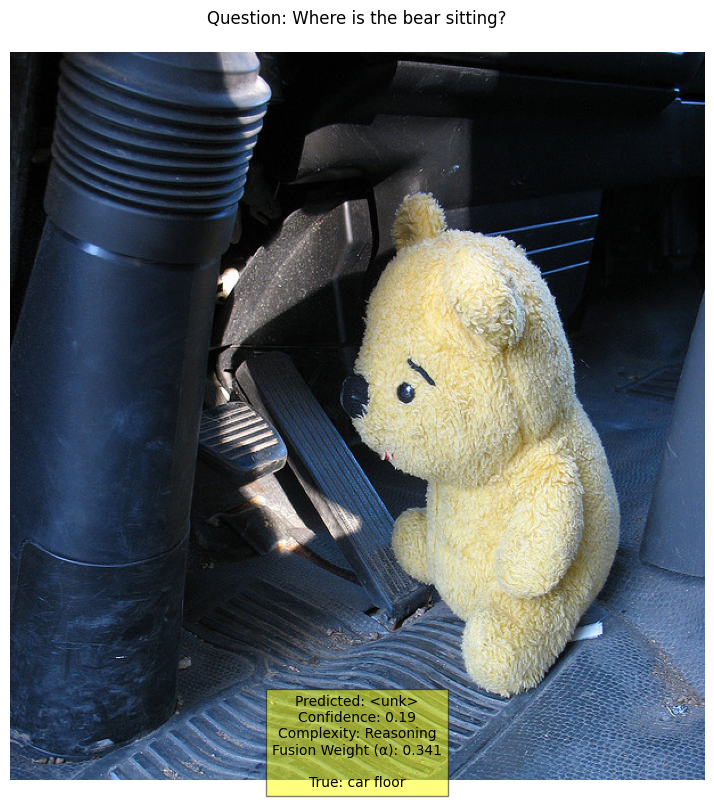


Sample 100:


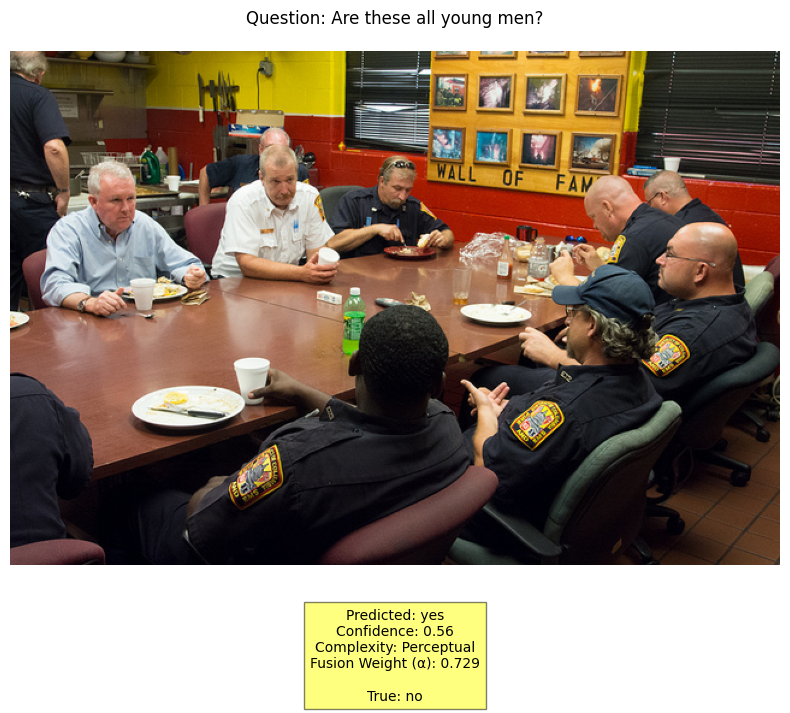


Sample 200:


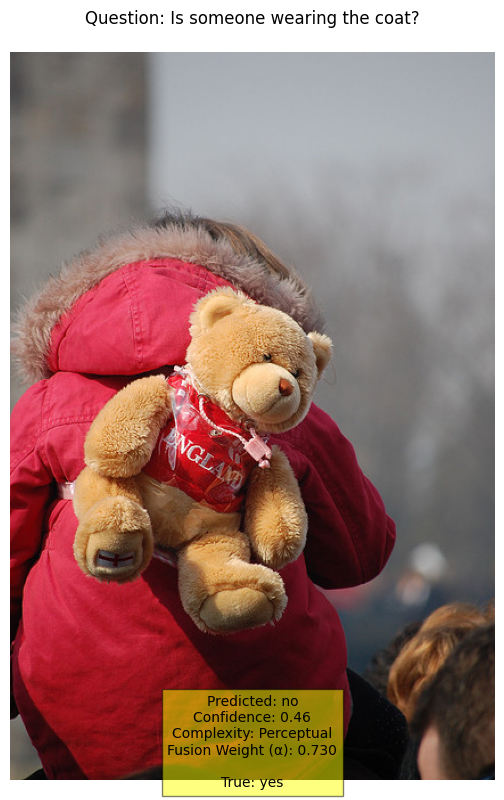

In [ ]:
# ============================================
# CELL 10: TEST ON SAMPLE IMAGES
# ============================================

def test_sample(image_path, question, true_answer=None):
    """Test model on a single example"""
    
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    image = image.resize((224, 224))
    image = np.array(image).transpose(2, 0, 1) / 255.0
    image = torch.FloatTensor(image).unsqueeze(0).to(device)
    
    # Tokenize question
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    tokens = tokenizer(question, return_tensors='pt',
                      padding='max_length', truncation=True,
                      max_length=32).to(device)
    
    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(image, tokens['input_ids'], tokens['attention_mask'],
                       mode='inference')
        
        pred_idx = torch.argmax(outputs['logits'], dim=1).item()
        pred_answer = train_dataset.idx_to_ans[pred_idx]
        alpha = outputs['alpha'][0].item()
        complexity = torch.argmax(outputs['complexity'][0]).item()
        comp_name = ['Perceptual', 'Reasoning'][complexity]
        
        # Get GPT-2 generation
        gpt_answer = outputs['generated_answers'][0] if outputs['generated_answers'] else None
    
    # Display
    plt.figure(figsize=(8, 8))
    img = Image.open(image_path)
    plt.imshow(img)
    plt.title(f"Question: {question}", fontsize=12, pad=20)
    plt.axis('off')
    
    result_text = f"Predicted: {pred_answer}\n"
    result_text += f"Confidence: {torch.max(torch.softmax(outputs['logits'], dim=1)).item():.2f}\n"
    result_text += f"Complexity: {comp_name}\n"
    result_text += f"Fusion Weight (α): {alpha:.3f}\n"
    if gpt_answer:
        result_text += f"GPT-2: {gpt_answer}"
    if true_answer:
        result_text += f"\nTrue: {true_answer}"
    
    plt.figtext(0.5, 0.01, result_text, ha='center', fontsize=10,
                bbox=dict(facecolor='yellow', alpha=0.5))
    plt.tight_layout()
    plt.show()
    
    return pred_answer

# Test on some samples
print("\n" + "="*70)
print("TESTING ON SAMPLE IMAGES")
print("="*70)

test_indices = [0, 100, 200]
for idx in test_indices:
    if idx < len(val_dataset):
        sample = val_dataset[idx]
        img_id = sample['image_id']
        img_path = f"{base_path}/data/mini_coco/val2014/COCO_val2014_{str(img_id).zfill(12)}.jpg"
        
        if os.path.exists(img_path):
            print(f"\nSample {idx}:")
            pred = test_sample(img_path, sample['question'], sample['answer_text'])